# t-SNE: Stochastic Neighbor Embedding for Visualization

This notebook explores t-SNE — a nonlinear dimensionality reduction
technique designed for visualization.

We analyze:

• Why PCA fails for visualization  
• t-SNE probability construction  
• KL divergence objective  
• Effect of perplexity  
• Comparison with PCA  
• Practical caveats

## Motivation: Why PCA Is Not Enough

PCA preserves global variance.

But visualization requires preserving local neighborhood structure.

For clustering or manifold visualization, we care about:

• Who is near whom  
• Local geometry  
• Cluster separation  

t-SNE focuses on preserving local similarities, not variance.

## Mathematical Idea Behind t-SNE

Step 1: Convert pairwise distances into probabilities.

High-dimensional similarity:

p_{j|i} = exp(-||x_i - x_j||² / 2σ_i²) / normalization

Symmetrize:

p_{ij} = (p_{j|i} + p_{i|j}) / 2n

Step 2: Define low-dimensional similarity using Student-t distribution:

q_{ij} = (1 + ||y_i - y_j||²)^(-1) / normalization

Step 3: Minimize KL divergence:

KL(P || Q) = Σ p_{ij} log(p_{ij} / q_{ij})

This forces nearby points in high dimension
to remain nearby in low dimension.

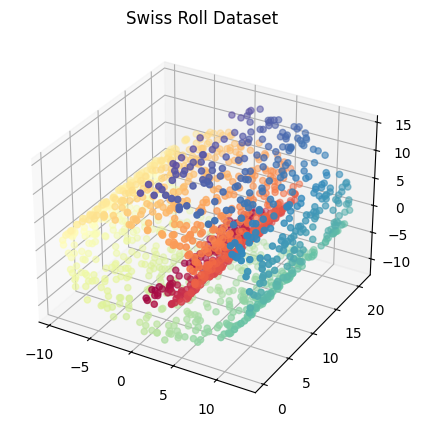

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

X, t = make_swiss_roll(n_samples=1500, noise=0.1, random_state=42)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=t, cmap="Spectral")
ax.set_title("Swiss Roll Dataset")
plt.show()

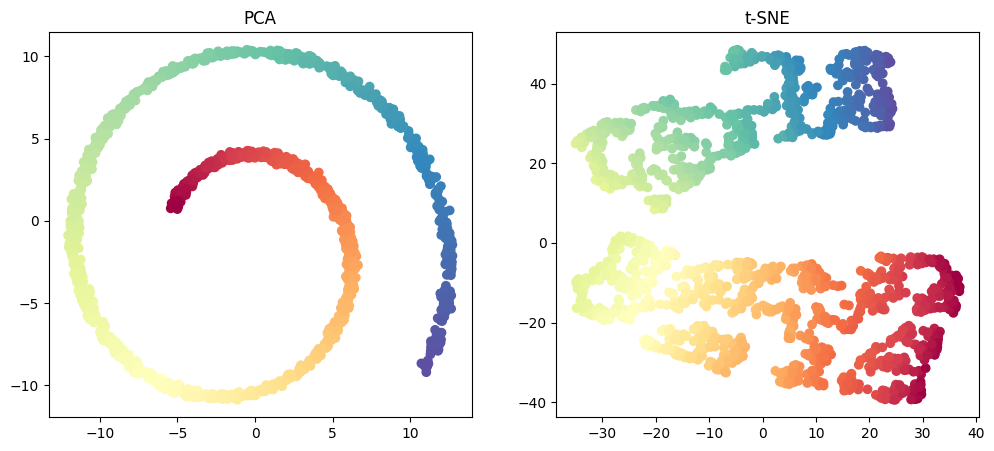

In [2]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(X_pca[:,0], X_pca[:,1], c=t, cmap="Spectral")
ax[0].set_title("PCA")

ax[1].scatter(X_tsne[:,0], X_tsne[:,1], c=t, cmap="Spectral")
ax[1].set_title("t-SNE")

plt.show()

### Observation

PCA overlaps layers.

t-SNE separates manifold structure more clearly.

t-SNE preserves local neighborhoods,
but does not preserve global geometry faithfully.

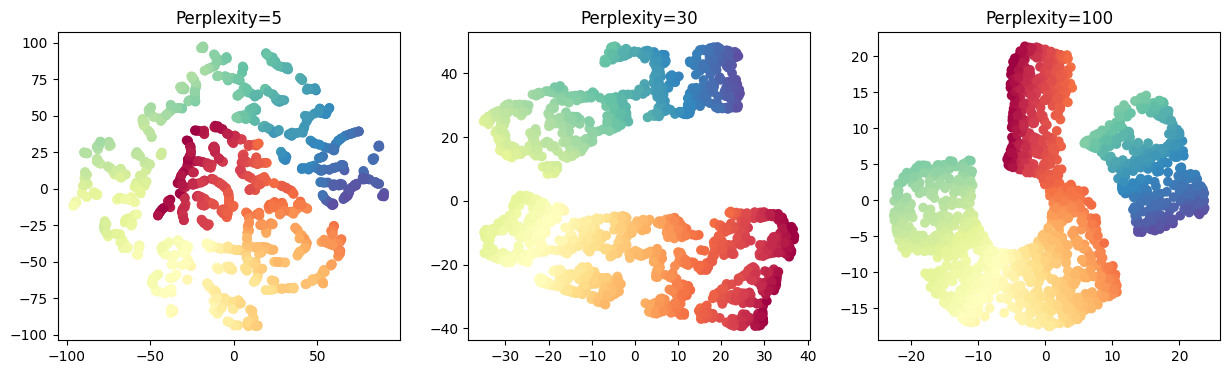

In [3]:
perplexities = [5, 30, 100]

fig, axes = plt.subplots(1,3, figsize=(15,4))

for perplexity, ax in zip(perplexities, axes):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X)
    ax.scatter(X_tsne[:,0], X_tsne[:,1], c=t, cmap="Spectral")
    ax.set_title(f"Perplexity={perplexity}")

plt.show()

### Effect of Perplexity

Small perplexity → very local focus → fragmented clusters  
Large perplexity → more global structure → smoother embedding  

Perplexity balances local vs global structure.

## The Crowding Problem

High-dimensional data has much more volume.

When projecting to low dimension,
there is not enough space to preserve all pairwise distances.

t-SNE uses heavy-tailed Student-t distribution in low dimension
to prevent points from collapsing together.

This helps separate clusters.

## Practical Considerations

• t-SNE is stochastic — results vary across runs  
• Does not preserve global distances  
• Not suitable for downstream modeling  
• Primarily for visualization  
• Computationally expensive (O(n²))

# Final Insights

• t-SNE preserves local similarity, not global variance  
• Optimizes KL divergence between probability distributions  
• Heavy-tailed low-dimensional distribution prevents crowding  
• Excellent for visualization  
• Not a general-purpose dimensionality reduction method  

t-SNE is a visualization tool, not a compression tool.

# Final Insights

Dimensionality reduction methods preserve different properties:

PCA → global variance  
Kernel PCA → nonlinear similarity  
Isomap → manifold geometry  
t-SNE → local neighborhoods

Choosing the correct method depends on the problem:

• Data compression → PCA  
• Nonlinear structure → Kernel PCA / Isomap  
• Visualization → t-SNE